# Import library

In [1]:
import rasterio
import torchgeo
import torch
import torch.nn as nn
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
# import pycuda.driver as cuda

In [2]:
# torch.cuda.is_available()

# Define function

In [3]:
# create image patches
# inherit from torch.nn.Module class
class Patchify(nn.Module):
    def __init__(self, patch_size=256):
        super().__init__()  # call the __init__ function of the parent class
        self.p = patch_size
        # unfold function is for extracting patches
        self.unfold = torch.nn.Unfold(kernel_size=patch_size, stride=patch_size) # stride = patch_size to avoid overlapping patches

    def forward(self, x):
        # x is input tensor
        # x -> Batch size, channels, height, width
        bs, c, h, w = x.shape
        
        x = self.unfold(x)
        # x -> Batch size, (channels*patch size*patch size), L (number of patches)
        
        # Reshaping into the shape we want -> view() helps flatten the input
        a = x.view(bs, c, self.p, self.p, -1).permute(0, 4, 1, 2, 3)
        # a -> ( B no.of patches c p p )
        return a

# Import data

## Sentinel-2 image

In [4]:
sentinel2_path = '../data/raw/sentinel-2/sentinel2_openeo_med_4months_dresden.geotiff'
data = rioxarray.open_rasterio(sentinel2_path)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [5]:
data.band

<xarray.DataArray 'band' (band: 13)> Size: 104B
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
    spatial_ref  int64 8B 0

In [6]:
data.sel(band=1).dtype

dtype('int16')

Min and max normalization give the worst result according to https://medium.com/sentinel-hub/how-to-normalize-satellite-images-for-deep-learning-d5b668c885af

In [7]:
# Normalize the bands to the range [0, 1]
def normalize(array):
    array_min, array_max = array.min(), array.max()
    return (array - array_min) / (array_max - array_min)

In [8]:
# 2th percentile to 98th percentile
# Apply a percentile-based contrast stretch (ignore the extreme values so image isn't too dark or too bright)
def contrast_stretch(array, lower_percentile=2, upper_percentile=98):
    lower = np.percentile(array, lower_percentile)
    upper = np.percentile(array, upper_percentile)
    array = np.clip(array, lower, upper) # clip -> limit the values in an array to specific range
    return (array - lower) / (upper - lower) # normalization

In [9]:
# 1th percentile to 99th percentile
# Apply a percentile-based contrast stretch (ignore the extreme values so image isn't too dark or too bright)
def contrast_stretch_new(array, lower_percentile=1, upper_percentile=99):
    lower = np.percentile(array, lower_percentile)
    upper = np.percentile(array, upper_percentile)
    print('lower: ', lower)
    print('upper: ', upper)
    array = np.clip(array, lower, upper) # clip -> limit the values in an array to specific range
    return (array - lower) / (upper - lower) # normalization

lower:  4.0
upper:  4145.0


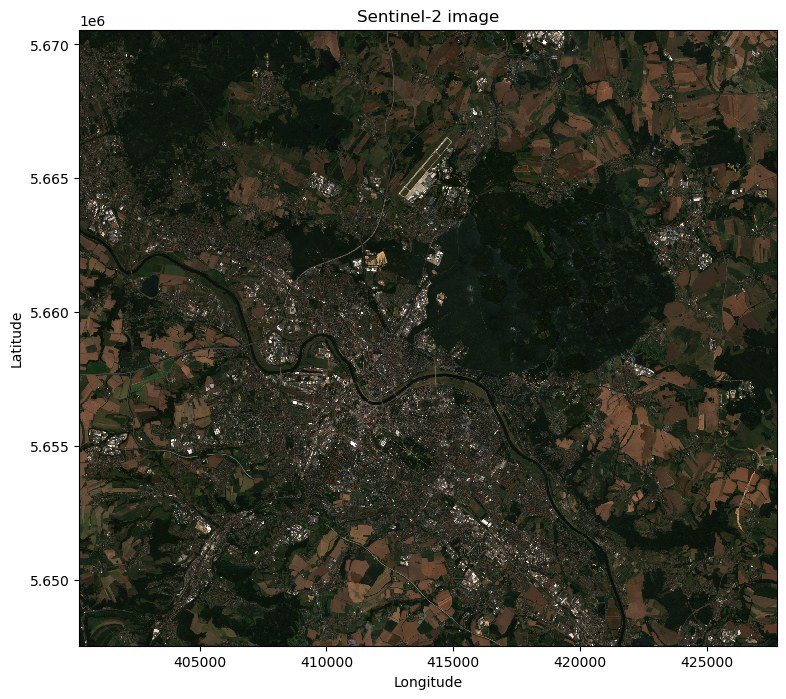

In [10]:
# Plot the raster data
plt.figure(figsize=(9,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
contrast_stretch_new(data).sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Binary mask

In [11]:
mask_path = '../data/processed/osm/public_green_spaces_dresden.geotiff'
mask_data = rioxarray.open_rasterio(mask_path)

In [12]:
mask_data = mask_data.astype('float32')

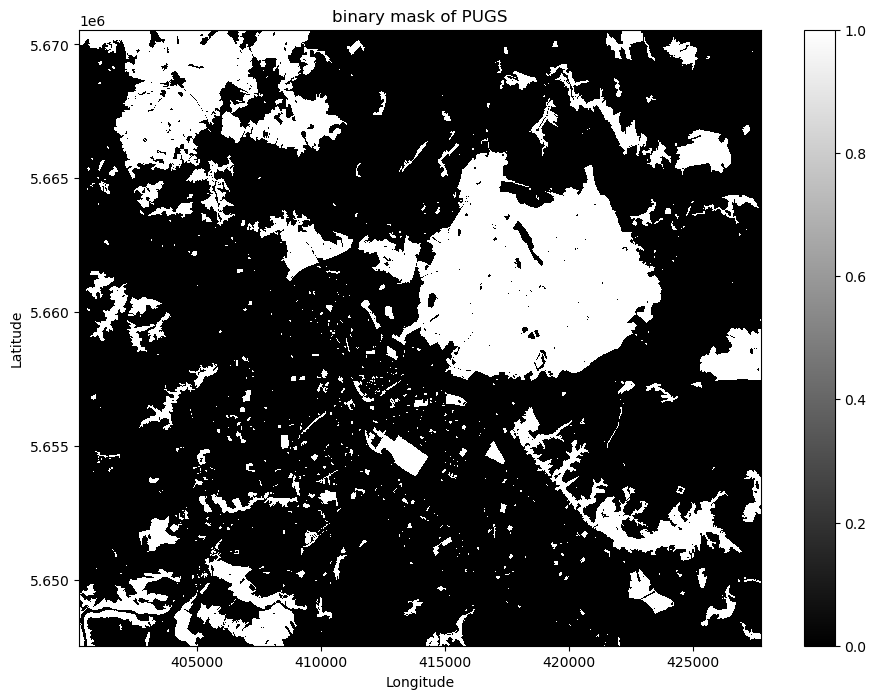

In [13]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
mask_data.sel(band=1).plot.imshow(cmap='gray')
plt.title("binary mask of PUGS")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## NDVI raster

In [14]:
ndvi_path = '../data/raw/sentinel-2/ndvi_sentinel2_openeo_med_4months_dresden.geotiff'
ndvi_data = rioxarray.open_rasterio(ndvi_path)

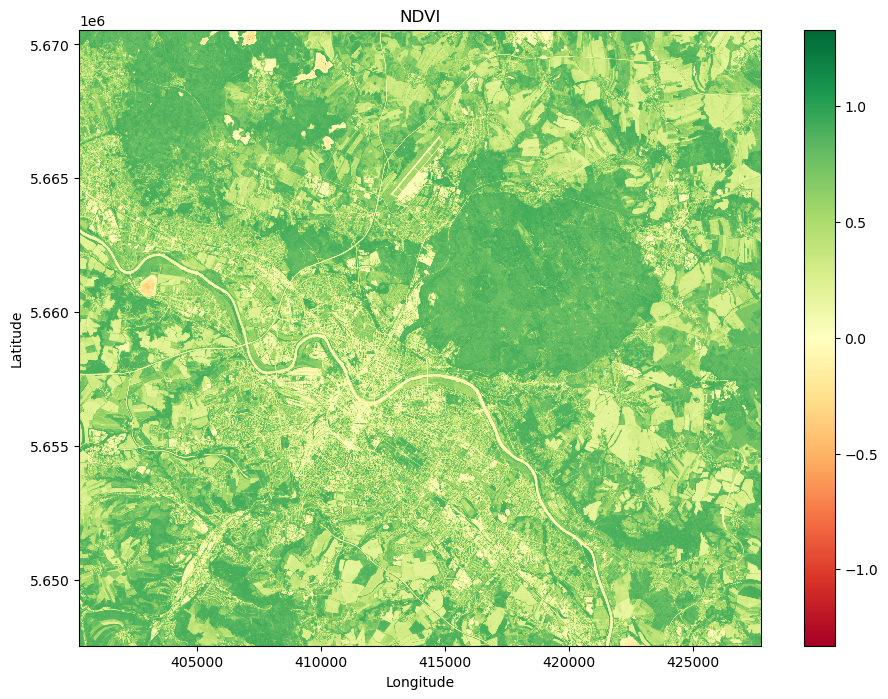

In [15]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
ndvi_data.sel(band=1).plot.imshow(cmap='RdYlGn')
plt.title("NDVI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## NDWI raster

In [16]:
ndwi_path = '../data/raw/sentinel-2/ndwi_sentinel2_openeo_med_4months_dresden.geotiff'
ndwi_data = rioxarray.open_rasterio(ndwi_path)

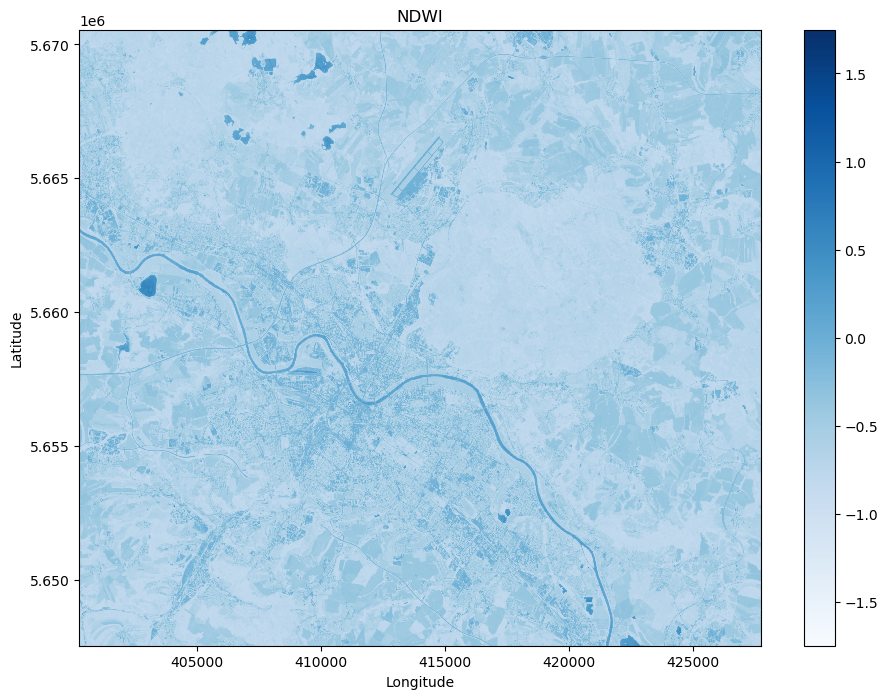

In [17]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
ndwi_data.sel(band=1).plot.imshow(cmap='Blues')
plt.title("NDWI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# NDBI raster

In [18]:
ndbi_path = '../data/raw/sentinel-2/ndbi_sentinel2_openeo_med_4months_dresden.geotiff'
ndbi_data = rioxarray.open_rasterio(ndbi_path)

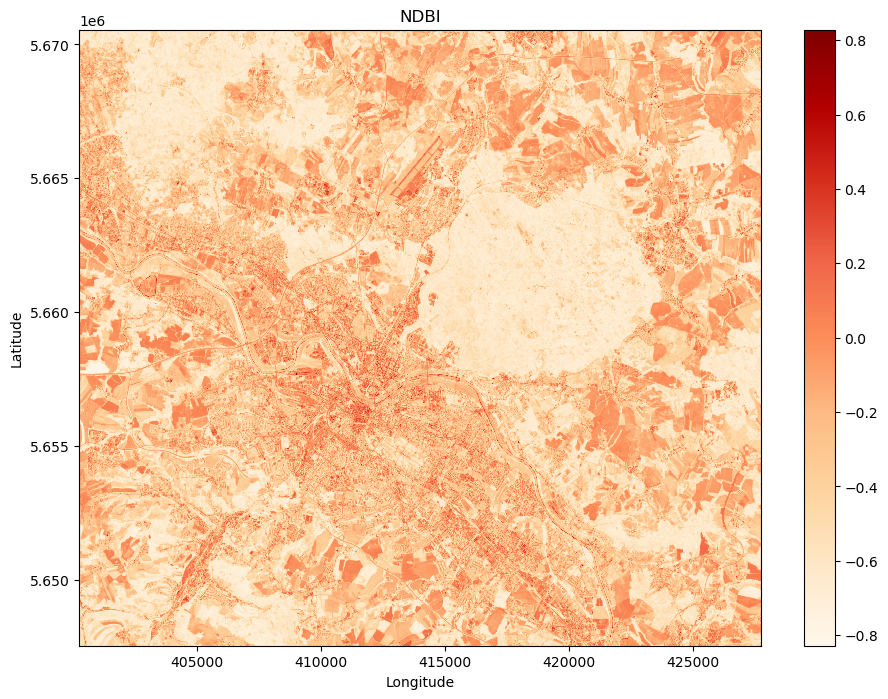

In [19]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
ndbi_data.sel(band=1).plot.imshow(cmap='OrRd')
plt.title("NDBI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Create image patches (use unfold function -> pytorch)

In [20]:
patch = Patchify()

In [21]:
# Sentinel-2 image

# Convert DataArray to NumPy array
# img = contrast_stretch(data).sel(band=[4, 3, 2]).values  # Convert xarray DataArray to NumPy

img = contrast_stretch(data).values
print("img length:", len(img))

# Check if it's a multi-band image
# if len(img.shape) == 3:  
#     img = np.stack([img[0], img[1], img[2]], axis=-1)  # RGB bands

# image = img.astype('float32') / 255.0  # Normalize to [0, 1]
image = torch.from_numpy(img)
print("image shape:", image.shape)

# image = image.permute(2, 0, 1) # change the order of the dimensions (height, width, channels) to (channels, height, width)
image = image.unsqueeze(0) # to add the batch dimension in the 0th position

p = patch(image)
p = p.squeeze() # to remove the batch dimension for plotting

img length: 13
image shape: torch.Size([13, 2301, 2747])


In [22]:
print(p.shape)

torch.Size([80, 13, 256, 256])


In [23]:
# binary mask

mask_img = mask_data.values
print("mask img length:", len(mask_img))

# Check if it's a multi-band image
# if len(img.shape) == 3:  
#     img = np.stack([img[0], img[1], img[2]], axis=-1)  # RGB bands

# image = img.astype('float32') / 255.0  # Normalize to [0, 1]
mask_image = torch.from_numpy(mask_img)
print("mask image shape:", mask_image.shape)

# image = image.permute(2, 0, 1) # change the order of the dimensions (height, width, channels) to (channels, height, width)
mask_image = mask_image.unsqueeze(0) # to add the batch dimension in the 0th position

mask_p = patch(mask_image)
# mask_p = mask_p.squeeze() # to remove the batch dimension for plotting

mask img length: 1
mask image shape: torch.Size([1, 2301, 2747])


In [24]:
# ndvi

ndvi_img = ndvi_data.values
print("NDVI img length:", len(ndvi_img))

# Check if it's a multi-band image
# if len(img.shape) == 3:  
#     img = np.stack([img[0], img[1], img[2]], axis=-1)  # RGB bands

# image = img.astype('float32') / 255.0  # Normalize to [0, 1]
ndvi_image = torch.from_numpy(ndvi_img)
print("NDVI image shape:", ndvi_image.shape)

# image = image.permute(2, 0, 1) # change the order of the dimensions (height, width, channels) to (channels, height, width)
ndvi_image = ndvi_image.unsqueeze(0) # to add the batch dimension in the 0th position

ndvi_p = patch(ndvi_image)
# ndvi_p = ndvi_p.squeeze() # to remove the batch dimension for plotting

NDVI img length: 1
NDVI image shape: torch.Size([1, 2301, 2747])


In [25]:
# ndwi

ndwi_img = ndvi_data.values
print("NDWI img length:", len(ndwi_img))

# Check if it's a multi-band image
# if len(img.shape) == 3:  
#     img = np.stack([img[0], img[1], img[2]], axis=-1)  # RGB bands

# image = img.astype('float32') / 255.0  # Normalize to [0, 1]
ndwi_image = torch.from_numpy(ndwi_img)
print("NDWI image shape:", ndwi_image.shape)

# image = image.permute(2, 0, 1) # change the order of the dimensions (height, width, channels) to (channels, height, width)
ndwi_image = ndwi_image.unsqueeze(0) # to add the batch dimension in the 0th position

ndwi_p = patch(ndwi_image)
# ndwi_p = ndwi_p.squeeze() # to remove the batch dimension for plotting

NDWI img length: 1
NDWI image shape: torch.Size([1, 2301, 2747])


In [26]:
# ndbi

ndbi_img = ndbi_data.values
print("NDBI img length:", len(ndbi_img))

# Check if it's a multi-band image
# if len(img.shape) == 3:  
#     img = np.stack([img[0], img[1], img[2]], axis=-1)  # RGB bands

# image = img.astype('float32') / 255.0  # Normalize to [0, 1]
ndbi_image = torch.from_numpy(ndbi_img)
print("NDBI image shape:", ndbi_image.shape)

# image = image.permute(2, 0, 1) # change the order of the dimensions (height, width, channels) to (channels, height, width)
ndbi_image = ndbi_image.unsqueeze(0) # to add the batch dimension in the 0th position

ndbi_p = patch(ndbi_image)
# ndbi_p = ndbi_p.squeeze() # to remove the batch dimension for plotting

NDBI img length: 1
NDBI image shape: torch.Size([1, 2301, 2747])


In [27]:
print(ndbi_p.shape)

torch.Size([1, 80, 1, 256, 256])


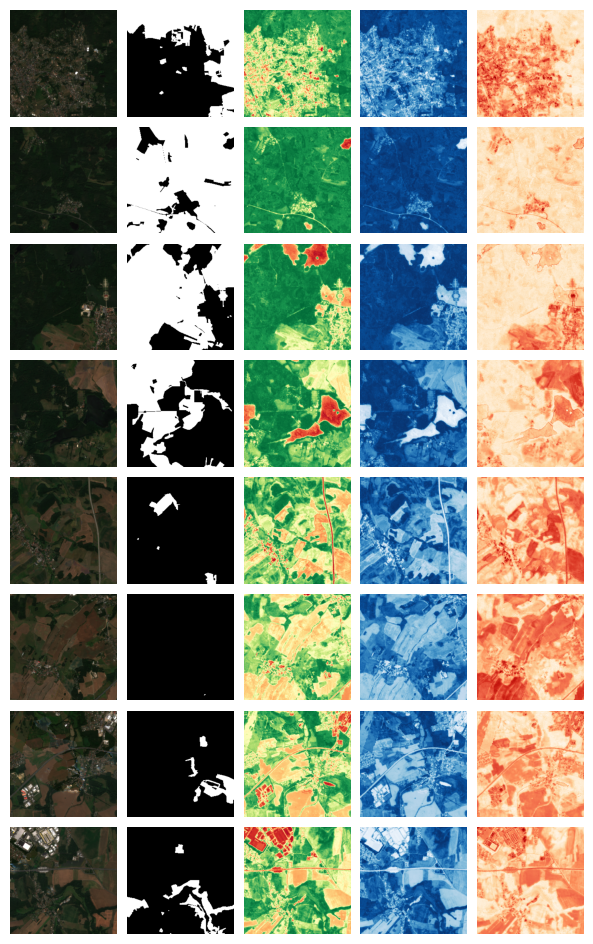

In [28]:
from mpl_toolkits.axes_grid1 import ImageGrid

def plot_patches(image_tensor, mask_tensor, ndvi_tensor, ndwi_tensor, ndbi_tensor):
    fig = plt.figure(figsize=(12, 12))
    grid = ImageGrid(fig, 111, nrows_ncols=(8, 5), axes_pad=0.1)

    # squeeze to remove the batch dimension for plotting
    image_tensor = image_tensor.squeeze()
    mask_tensor = mask_tensor.squeeze()
    ndvi_tensor = ndvi_tensor.squeeze()
    ndwi_tensor = ndwi_tensor.squeeze()
    ndbi_tensor = ndbi_tensor.squeeze()

    for i in range(int(len(grid)/5)):
        # plot the image patch
        temp_tensor = image_tensor[i].permute(1, 2, 0)
        patch = np.stack([temp_tensor[:, :, 3], temp_tensor[:, :, 2], temp_tensor[:, :, 1]], axis=-1)  # RGB bands
        ax_image = grid[5 * i]
        # format of imshow function is (height, width, channels)
        ax_image.imshow(patch)
        ax_image.axis('off')

        # plot the corresponding mask
        ax_mask = grid[5 * i + 1]
        ax_mask.imshow(mask_tensor[i], cmap='gray')
        ax_mask.axis('off')

        # plot ndvi
        ax_ndvi = grid[5 * i + 2]
        ax_ndvi.imshow(ndvi_tensor[i], cmap='RdYlGn')
        ax_ndvi.axis('off')

        # plot ndwi
        ax_ndwi = grid[5 * i + 3]
        ax_ndwi.imshow(ndwi_tensor[i], cmap='Blues')
        ax_ndwi.axis('off')

        # plot ndbi
        ax_ndbi = grid[5 * i + 4]
        ax_ndbi.imshow(ndbi_tensor[i], cmap='OrRd')
        ax_ndbi.axis('off')

    # for i, ax in enumerate(grid):
    #     temp_tensor = tensor[i].permute(1, 2, 0)
    #     patch = np.stack([temp_tensor[:,:,3], temp_tensor[:,:,2], temp_tensor[:,:,1]], axis=-1)  # RGB bands
    #     # format of imshow function is (height, width, channels)
    #     ax.imshow(patch)
    #     ax.axis('off')

    plt.show()

plot_patches(p, mask_p, ndvi_p, ndwi_p, ndbi_p)

test save patch

In [29]:
from torch.utils.data import DataLoader

from torchgeo.datasets import RasterDataset, stack_samples, unbind_samples, utils
from torchgeo.samplers import RandomGeoSampler, Units
from torchgeo.transforms import indices

In [30]:
train_dataloader = DataLoader(
    p, batch_size=4, collate_fn=stack_samples
)

In [37]:
examples = next(iter(train_dataloader))

AttributeError: 'Tensor' object has no attribute 'items'